Loading base data & extracting CSI 300 universe...
Total historical stocks in CSI 300 universe: 584
Calculating dividend factors for CSI 300 stocks...


Processing stocks: 5693it [32:27,  2.92it/s]                                                                           


Merging industry info to factor table...
Executing daily stock selection (Industry Neutral)...
Starting backtest loop for CSI 300 portfolio...

--- Performance Metrics (CSI 300 Dividend + Neutral) ---
Annualized Return: 0.1539
Volatility: 0.1876
Sharpe Ratio: 0.8204
Max Drawdown: -0.1592


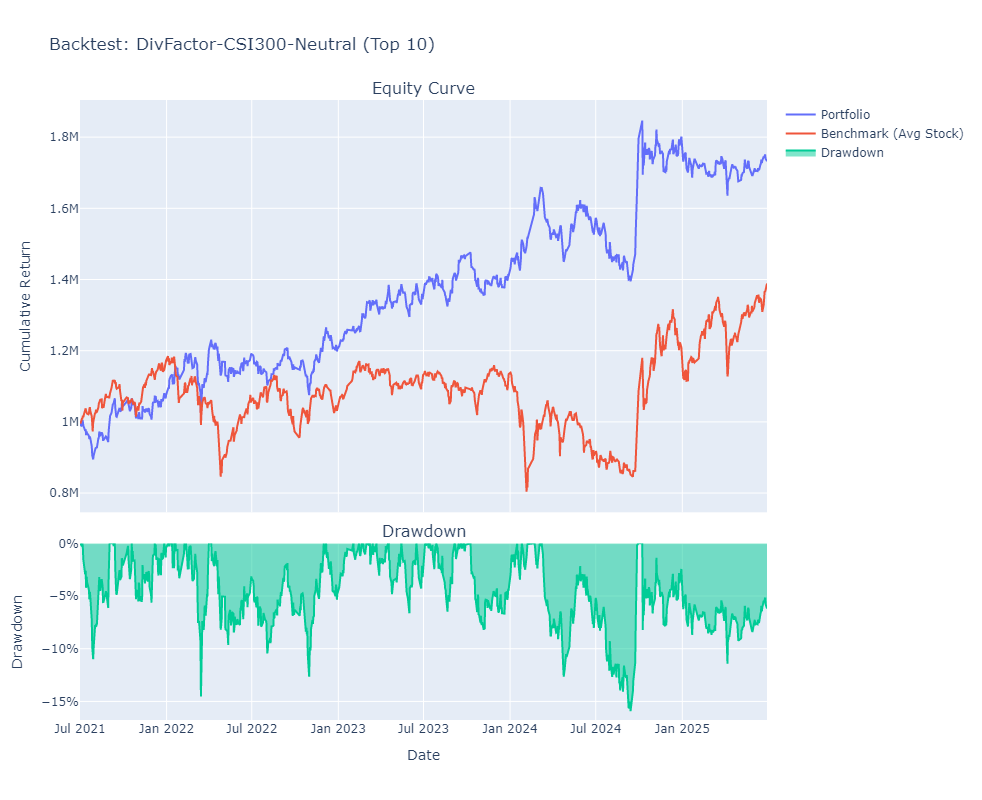

In [12]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize
from datetime import datetime, timedelta
from warnings import filterwarnings
from tqdm import tqdm
from util import (calc_factors, load_and_preprocess_price, load_selection,
                  get_top_n_selection, compute_benchmark_returns,
                  compute_metrics, plot_results)

filterwarnings('ignore')

# ----------------------------
# 0. 用户配置参数 (对应沪深300)
# ----------------------------
stock_num = 5               # 每个行业选5只
INITIAL_CASH = 1_000_000
START_DATE = '2020-01-01'
END_DATE   = '2025-06-30'
REBALANCE_FREQ = 5
TOP_N = 10                  # 最终组合选Top 10

PRICE_FILE = 'eod_prices.parquet'
DIVIDEND_FILE = 'dividend.parquet'
FUND_FILE = 'ETF_hold_510300.SH.parquet'   # 已修改为沪深300 ETF持仓数据
INDUSTRY_FILE = 'Stock_Industry_Year.parquet'

# ----------------------------
# 1. 数据预处理 & 股票池过滤 (锁定沪深300)
# ----------------------------
print("Loading base data & extracting CSI 300 universe...")
dividend = pd.read_parquet(DIVIDEND_FILE)
price_dt = pd.read_parquet(PRICE_FILE)
fund_df = pd.read_parquet(FUND_FILE)
industry_df = pd.read_parquet(INDUSTRY_FILE)

# 统一日期格式
dividend['announce_date'] = pd.to_datetime(dividend['announce_date'])
dividend['ex_date'] = pd.to_datetime(dividend['ex_date'])
price_dt['trade_date'] = pd.to_datetime(price_dt['trade_date'])

# 处理ETF持仓日期逻辑 (来自代码1框架)
fund_df = fund_df.rename(columns={'end_date': 'report_end_date'}) 
fund_df['report_end_date'] = pd.to_datetime(fund_df['report_end_date'])

def get_position_valid_period(row):
    year = row['report_year']
    if row['report_type'] == '中报':
        start_date = pd.to_datetime(f'{year}-01-01')
        end_date = pd.to_datetime(f'{year}-06-30')
    elif row['report_type'] == '年报':
        start_date = pd.to_datetime(f'{year}-07-01')
        end_date = pd.to_datetime(f'{year}-12-31')
    else:
        start_date = end_date = row['report_end_date']
    return pd.Series([start_date, end_date], index=['pos_start_date', 'pos_end_date'])

fund_df[['pos_start_date', 'pos_end_date']] = fund_df.apply(get_position_valid_period, axis=1)
fund_holdings = fund_df[['stock_code', 'pos_start_date', 'pos_end_date']].drop_duplicates()

# 【关键优化】仅针对沪深300历史持仓股过滤
csi_300_stocks = fund_holdings['stock_code'].unique()
print(f"Total historical stocks in CSI 300 universe: {len(csi_300_stocks)}")

price_dt_subset = price_dt[price_dt['stock_code'].isin(csi_300_stocks)].sort_values(['stock_code', 'trade_date'])
dividend_subset = dividend[dividend['stock_code'].isin(csi_300_stocks)].sort_values(['stock_code', 'announce_date'])

# ----------------------------
# 2. 因子计算 (仅针对沪深300股票)
# ----------------------------
print("Calculating dividend factors for CSI 300 stocks...")
df_factors_list = []
total_stocks = price_dt_subset['stock_code'].nunique()

for stock, price_sub in tqdm(price_dt_subset.groupby('stock_code'), total=total_stocks, desc="Processing stocks"):
    if stock in dividend_subset['stock_code'].values:
        div_sub = dividend_subset[dividend_subset['stock_code'] == stock]
        factor_sub = calc_factors(price_sub, div_sub) 
        df_factors_list.append(factor_sub)
    else:
        temp_df = price_sub[['stock_code', 'trade_date']].copy()
        temp_df['expected_div_yield'] = 0.0
        temp_df['static_div_yield'] = 0.0
        temp_df['dynamic_div_yield'] = 0.0
        df_factors_list.append(temp_df)

div_factor_dt = pd.concat(df_factors_list, ignore_index=True)

# 合并行业信息 (通过年度关联)
print("Merging industry info to factor table...")
div_factor_dt['year'] = div_factor_dt['trade_date'].dt.year
industry_df['year'] = industry_df['year'].astype(int)
div_factor_dt = div_factor_dt.merge(industry_df[['stock_code', 'year', 'industry_name']], 
                                    on=['stock_code', 'year'], 
                                    how='left')

# ----------------------------
# 3. 核心选股逻辑 (沪深300 + 行业中性)
# ----------------------------
print("Executing daily stock selection (Industry Neutral)...")

def select_stocks_by_date(date_group):
    trade_date = date_group.name
    daily_data = date_group.copy()
    
    # 基于日期筛选沪深300当期持仓
    valid_holdings = fund_holdings[
        (fund_holdings['pos_start_date'] <= trade_date) & 
        (fund_holdings['pos_end_date'] >= trade_date)
    ]['stock_code'].tolist()
    holding_stocks = daily_data[daily_data['stock_code'].isin(valid_holdings)]
    
    if len(holding_stocks) == 0:
        return pd.DataFrame() 
    
    # 剔除空值并缩尾
    holding_stocks = holding_stocks.dropna(subset=['dynamic_div_yield', 'industry_name'])
    if len(holding_stocks) == 0:
        return pd.DataFrame()

    holding_stocks['div_winsorized'] = winsorize(
        holding_stocks['dynamic_div_yield'].values, 
        limits=(0.01, 0.01),
        inclusive=(True, True)
    )
    
    # 行业内取股息率最高的 Top N
    selected = holding_stocks.groupby('industry_name', group_keys=False).apply(
        lambda x: x.sort_values('div_winsorized', ascending=False).head(stock_num)
    )
    
    selected = selected.sort_values('div_winsorized', ascending=False)
    selected['selection_rank'] = range(1, len(selected)+1)
    return selected

selected_stocks = div_factor_dt.groupby('trade_date', group_keys=False).apply(select_stocks_by_date)
selected_stocks = selected_stocks.reset_index(drop=True)
final_selection_df = selected_stocks[['trade_date', 'stock_code', 'industry_name', 'dynamic_div_yield', 'div_winsorized', 'selection_rank']]

# ----------------------------
# 4. 回测循环
# ----------------------------
print("Starting backtest loop for CSI 300 portfolio...")
price_pivot = price_dt.pivot(index='trade_date', columns='stock_code', values='adjusted_close')
price_pivot = price_pivot.sort_index()
price_pivot.index = pd.to_datetime(price_pivot.index)

price_pivot = price_pivot.loc[START_DATE:END_DATE]
selection_df = final_selection_df[(final_selection_df['trade_date'] >= START_DATE) &
                                  (final_selection_df['trade_date'] <= END_DATE)]

selection_dates = sorted(selection_df['trade_date'].unique())
rebalance_dates = selection_dates[::REBALANCE_FREQ]
all_dates = price_pivot.index.tolist()
first_rebalance = rebalance_dates[0]
timeline = [d for d in all_dates if d >= first_rebalance]

cash = INITIAL_CASH
holdings = {}
portfolio_values = []

benchmark_daily, benchmark_cum = compute_benchmark_returns(price_pivot, START_DATE, END_DATE)

for date in timeline:
    today_prices = price_pivot.loc[date]
    if date in rebalance_dates:
        # Sell
        for stock, shares in holdings.items():
            price = today_prices.get(stock, np.nan)
            if pd.notna(price): cash += shares * price
        holdings = {}
        # Select (基于排名的全局 Top N)
        selected = get_top_n_selection(selection_df, date, TOP_N)
        # Buy
        if selected:
            valid_stocks = [s for s in selected if pd.notna(today_prices.get(s, np.nan))]
            if valid_stocks:
                amount_per_stock = cash / len(valid_stocks)
                for stock in valid_stocks:
                    price = today_prices[stock]
                    holdings[stock] = amount_per_stock / price
                cash = 0.0

    # Total Value Calculation
    current_value = cash + sum(shares * today_prices.get(stock, 0) 
                               for stock, shares in holdings.items() 
                               if pd.notna(today_prices.get(stock, np.nan)))
    portfolio_values.append(current_value)

# ----------------------------
# 5. 评价与绘图
# ----------------------------
portfolio_series = pd.Series(portfolio_values, index=timeline, name='Portfolio')
# 归一化基准
benchmark_funds = INITIAL_CASH * (benchmark_cum.reindex(timeline, method='ffill') / benchmark_cum.loc[timeline[0]])

portfolio_returns = portfolio_series.pct_change().dropna()
metrics = compute_metrics(portfolio_returns, rf=0, periods_per_year=252)

print("\n--- Performance Metrics (CSI 300 Dividend + Neutral) ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

plot_results(portfolio_series, benchmark_funds, timeline, 
             title='Backtest: DivFactor-CSI300-Neutral (Top {})'.format(TOP_N))